hey


# Chapter 12: Edge Based Image Segmentation

In Chapter 11, we studied  region based image segmentation techniques, where we grouped the pixels under the same  region index with respect to a predefined similarity predicate by using region growing, split and merge, and clustering methods. 

In some application domains, region based segmentation may not be sufficient to partition images into meaningful regions, which represent objects.  Specifically, when the objects consist of  textured regions or collections of different colors, shapes and patterns, the pixels in the object region are no longer similar with respect to a similarity predicate. In such cases, detecting the  lines, curves, circular arcs and/or object boundaries carry important information about  the objects.

 **Motivating Question**: What defines an object?

The concept of object is widely studied  in cognitive science and experimental psychology. What is an object  and what is not,  depends on the  scene context. Unfortunately, there is no universal definition, which is valid for all types of objects in an  image datasets. 

Gestalt law, briefly explained in Chapter:2,  seeks to formalize this subjective concept to a certain extent. Recall that according to Gestalt theory, the following laws  affect whether  a variety of regions should be grouped together under the same object concept:

-  **Similarity**: Similar shapes  tend to be grouped together to form a single object.
- **Symmetry**: Collection of lines or curves that lead to symmetric groups tend to form a single object.
-  **Proximity**: If the multiple regions  are nearby, they tend to be grouped under the same object.
-  **Common fate**: Multiple regions that have coherent motion, tend to be grouped under one whole object. 
- **Common region**: A set of small regions  that lie inside the same closed region tend to be grouped together.
- **Parallelism**: Parallel lines or  curves tend to be grouped together under the same object.
- **Closure**: Collection of lines  or curves that  lead to closed curves tend to be grouped together to form object boundaries.
- **Continuity**: Several continuous nearby curves  tend to be grouped under a continuous boundary.
- **Familiar configuration**: A set  of regions, which resembles a familiar object,  tends to be grouped together to make that  object.

Consider the images of Figure 1. It is obvious that none of the region based image segmentation algorithms identify the flock of ducks, stadium, flower filed, sculpture and face.  All of these objects consist of more than one homogenous region. However, one can incorporate a series of Gestalt laws in a segmentation algorithm to extract these objects. For example; the stadium can be defined as a set of parallel curves lines, which are close to each other by using the law of similarity, proximity and parallelism. Similarly, we can design a segmentation algorithm for extracting the flock of ducks by extracting the nearby duck shaped regions that have approximately the same size and color by using the laws of similarity, proximity and familiar configuration.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/Gestaltlaws.png"  height=400px><figcaption>Figure 1:  Gestalt Laws can be incorporated to define the objects, which consists of group of composite region. For example, a bus object consists of parallel lines. A sculpture has a specific texture. Note that none of the objects in this figure can be extracted by a region based segmentation method.  </figcaption></p></figure>


The images of Figure 2 can be recognized by using shape and texture information. For example, in order to retrieve the image of bicycle in an image database,  the detection of circular shapes provide  very useful clues.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/Gestaltlaws2.png"  height=400px><figcaption>Figure 2:  Objects may be segmented by using shape and texture information. Bus and street image consist of parallel lines, grass consists of some texture. Bicycle consists of circular shapes.  </figcaption></p></figure>

Edge based segmentation methods offer an alternative to the region based segmentation methods by extracting object boundaries. It is possible to combine region based and edge based methods, in the light of Gestalt laws, for a complete segmentation.

Figure 3 shows several outputs of an edge based segmentation algorithm. Note that, although the object regions do not consist of similar pixels with respect to a color similarity predicate, they form a closed boundary with respect to some dissimilarity measures.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image1.png"  height=400px><figcaption>Figure 3: Examples of edge based image segmentation. (Courtesy of Selim Aksoy) </figcaption></p></figure>

# Edge Based Segmentation

Edge based segmentation algorithms seek for the abrupt change in pixel brightness values, which may represent the object boundaries.   In other words, rather than extracting the regions with respect to a similarity measure, edge based segmentation algorithms  attempt to  extract the pixels with respect to a **dissimilarity measure**. Most of these pixels  are expected to lie on the object boundary.

Recall that dissimilarities, which correspond to the abrupt changes among the pixels, can be detected by convolving the image with an edge filter. The edge map obtained at the output of the convolution filter consists of a lot of spurious edge pixels, which do not lie on an object boundary. Additionally, the edge detectors may skip some of the crucial edge pixels on the object boundary. In summary, edge maps fall too short to extract closed object boundaries, which partition an image into meaningful regions. Figure 4 shows the output of an edge detection algorithm. As it can be observed from this figure, there are many spurious edges in this image due to poor illumination, shades, occlusion, textures etc. Furthermore, some of the important edges, which form the boundary of the tiger, are missing. Therefore, one needs to further process an edge map to extract the closed boundaries  of objects.

There are two major steps of an edge based segmentation method:


**Step 1:**  Obtain an edge map at the output of an edge detection algorithm.  This  step requires designing a series of convolutional filters. First, we may need to smooth the image to remove undesired discontinuities. Then, we may   detect the edges using a set of edge filters.  

**Step 2:** Given the edge map obtained at the output of Step 1, extract a set of closed boundaries  from  the edge map. This step requires several algorithms for 
- pruning the weak edges, 
- detecting the isolated points, lines, circles and curves,
- closing the gaps between the line and curve segments and  finding a closed boundary. 

Figure 5 shows the output of a boundary extraction algorithm, which prunes many edges. It also completes the missing edges to form a closed boundary.


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image16.png"  height=400px><figcaption>

Figure 4: Edge Map obtained at the output of an edge detection algorithm. </figcaption></p></figure>


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/cats2.jpg"  height=400px><figcaption>

Figure 5: Edge map of image in Figure 4, obtained in Step 1 and  the boundary maps of the same image obtained in Step 2.  </figcaption></p></figure>

In order to develop a complete  edge based segmentation algorithm, the above steps can be iterated with different sets of filters, depending on the goal and application domains. In both  steps mentioned above,  Gestalt theory can be incorporated for extracting a meaningful boundary from a set of edge points.
 
In the following, we overview some basic algorithms for implementing the above mentioned steps of the edge based segmentation.


## Step 1: Obtaining the Edge Map

We have already seen smoothing and sharpening  filters in Chapter 4, which can be combined  to detect the  edges as the  local intensity differences using gradient and Laplacian Filters. 

Recall that the gradient (first derivative) of a continuous image $f(x,y)$ at location, $(x,y)$ is defined as a 2-dimensional  vector;
$$ \nabla f = [\frac{\partial f}{\partial x} \quad \frac{\partial f}{\partial y}]^T.$$

 Gradient operator, has a **magnitude**,

$$ |\nabla f(x,y)| = ((\frac{\partial f}{\partial x})^2 + (\frac{\partial f}{\partial y})^2)^\frac{1}{2},$$
which gives the  rate of change of $f(x,y)$ per unit distance in the **direction** of $\measuredangle \nabla f(x,y)$ , which is defined as,
$$\measuredangle\nabla f(x,y))= \tan ^{-1} [\frac{\frac{\partial f}{\partial y}}{ \frac{\partial f}{\partial x}}],$$ 

which represents the direction of this change with respect to the $x$-axis.

 Recall, also, that Laplacian Filters are the second derivative filters, without any direction, as defined below,

$$\nabla^2f(x,y) = \frac{\partial^2f(x,y)}{\partial x^2} + \frac{\partial^2f(x,y)}{\partial y^2}.$$

**Observations :**

- Gradient masks produce high absolute values at points of high contrast. They also provide direction of the edge.
- Laplacian masks produce double edges without any directions.  However, zero-crossings of the Laplacian maps  can be used for edge localization.

Figure 6 shows the cross sections of the gradient and Laplacian operators. As it can be observed from this figure, the gradient operator generates thick flat edges, whereas the Laplacian operator generates a double edge.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image25.png"  height=400px><figcaption>Figure 6: Gradient and Laplacian operators for 1D cross section. (From gonzales and Woods)</figcaption></p></figure>


Gradient and Laplacian of a 2- dimensional continuous  function can be approximated by convolving the image with gradient and Laplacian masks . Figure 7 shows popular gradient masks used for detecting vertical, horizontal, left and right diagonal edges.


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image24.png"  height=400px><figcaption> 

Figure 7: Simple edge detectors.




The output of the convolution of an image with a mask yields  a gray scale image, where the high values correspond to strong edges and low values correspond to relatively smooth areas. One needs to threshold the output of the convolution operation to obtain the binary edge map, which shows the location of the edge pixels. Determining  the size and selecting the direction of the gradient mask, as well as selecting a binarization threshold value is a design issue, which depends on the application domain. 

Figure 8 shows the output of the convolution of the block image with Sobel edge mask, where the lowest value is mapped to black and the highest value is mapped to white. The rest of the gray values correspond to the normalized output of the convolution.  Notice that the output of convolution consists of a wide range of gray values (“Figure 8, middle image).  Thresholding this output yields a binary edge map (Figure 8, right image).


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image23_new.png"  height=400px><figcaption>Figure 8: Gradient operators. a) Original image, b) gradient  magnitude obtained by Sobel edge detector and c) thresholded gradient  
magnitudes of Sobel edge detector. (Adapted from Linda Shapiro, U of Washington)</figcaption></p></figure>

Similarly Laplacian operators defined for the 2- dimensional continuous functions can be approximated by Laplacian edge masks, as shown in Figure 9. The output of the convolution of a face image with a Laplacian mask also consists of gray scale colors to be further thresholded for obtaining a binary edge map. 

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image19_new.png"  height=400px><figcaption>Figure 9: Laplacian operators in 2-D Digital Images</figcaption></p></figure>

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image30.png"  height=400px><figcaption>Figure 10: The output (right)  of convolution of a face image (left) with a  Laplacian operator mask. </figcaption></p></figure>

In most practical applications, a Gaussian smoothing filter is applied  prior to the edge detection to remove the texture, which may result in spurious edges. Recall that a one dimensional Gaussian function is defined as follows;

$$g(x) = \frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{x^2}{2\sigma^2}},$$

where $\sigma$ is the standard deviation, which gives a measure for the degree of flatness (randomness) of the Gaussian function. When we take the derivative of a Gaussian function, we obtain Gradient of Gaussian function, as follows:

 $$\frac{dg(x)}{dx} = \frac{-x}{\sigma^2}g(x).$$ 

Gradient of a Gaussian function smooths and detects the abrupt changes all at once, as shown in Figure 12.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image26.png"  height=400px><figcaption>Figure 11: One dimensional Gaussian function (left) and its derivative (right) , which smooths an image and detects the  edges of a smoothed image, all at ones. </figcaption></p></figure>

Two dimensional extensions of the gradient of Gaussian to detect vertical and horizontal edges are shown in Figure 12.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image28.png"  height=400px><figcaption>Figure 12 :Two-dimensional gradient of Gaussian masks, which smooths and detects the vertical and horizontal edges.</figcaption></p></figure>



Similarly, the second derivative of a one dimensional Gaussian function is called Laplacian of Gaussian (LoG):

 $$\frac{d^2g(x)}{dx^2} = (\frac{x^2}{\sigma^4} - \frac{-1}{\sigma^2}) g(x).$$




<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image48.png"  height=400px><figcaption>
Figure 13: Two-Dimensional continuous Gaussian smoothing and edge detection functions: Gaussian function (left), gradient of Gaussian function (middle), Laplacian of Gaussian function (right). (From Selim Aksoy, Adapted from Steve Seitz, U of Washington)</figcaption></p></figure>


## Scale Space Representation for  Edge Detection

The Laplacian of Gaussian filtering, mentioned above, smooths the image and removes noise with a single filter. However, the  smoothing process may lose important edge pixels.   The amount of smoothing is controlled by the standard deviation, $\sigma$ of the Gaussian function.  Larger σ corresponds to more  blurs and high risk of removal of important edges. On the other hand, small $\sigma$ results in too many edge pixels outside the object boundaries. Thus, there is a trade-off between smoothing and edge detection. 

In a two dimensional discrete grid, the size of the edge  mask is proportional to the standard deviation, $\sigma$. Figure 14 shows a 5x5 approximation of Laplacian of Gaussian mask, for $\sigma =1$, whereas Figure 15 shows a 11x11 mask with $\sigma =2$.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image31.png"  height=400px><figcaption>
Figure 14: Laplacian of Gaussian (a) Two- dimensional plot of the negative of the LoG. (b) Negative of the LoG displayed as an image. (c) Cross section of (a) showing zero crossings. (d) 5x5 mask approximation to the shape in (a). The negative of this mask would be used in practice. (Adapted from Gonzales and Woods)</figcaption></p></figure>

*<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image32.png"  height=400px><figcaption>Figure 15: Laplacian of Gaussian: An 11x11 mask approximating the LoG with $\sigma^2 = 2$. (From Selim Aksoy, From Harlick and Shapiro, Volume I,  page 349.)</figcaption></p></figure>



When we convolve the image of Figure 16 with these two masks, we obtain edges in different scales. Note that the output of filtering with 11x11 mask has much less edge pixels to that of 5x5 mask.

*<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image81.png"  height=400px><figcaption>Figure: 16: Edge maps obtained at different scales by convolving the image(left) with two Laplacian or Gaussian mask of sizes 5x5 and 11x11 (middle). The zero crossings of the convolution (right).</figcaption></p></figure>

The multiple representation of edge maps  at all possible scales of $\sigma$ is called **scale space representation**. There are a wide range of methods to detect a single edge map from scale space representation.  They use some heuristics to combine the edge maps or select one of the scales. 

One way of combining the edge maps is to accept the edge pixels, which are shared by  an  empirically defined range of scales. Another approach is to select the edge map with a  scale, which provides the “best fit”  to the boundary pixels. In order to find the “best fit” one needs a set of images with labeled object boundaries and a similarity criterion to compare the edge maps to the labeled boundary pixels. 


## Marr- Hildreth Edge Detectors

Marr and Hildreth proposed to combine a Laplacian of Gaussian Filter with the Gradient filter. They prune the edge map obtained at the output of  Laplacian of Gaussian filter by discarding the weak edges, where  the magnitude of the gradient filter is less than a predefined threshold. The basic steps of the Marr-Hildreth edge detection algorithm is given below:

**Algorithm: Marr-Hildreth Edge Detection**

Input: Image $f(x,y)$, size of the Laplacian of Gaussian and gradient filters, threshold value to prune the edges.
Output:  Marr-Hildreth Edge map.

Step 1: Convolve the image with  the Laplacian of Gaussian filter  and find  the zero crossings.
Step 2: Convolve the image by gradient filters defined in horizontal, vertical, left diagonal and right diagonal directions and keep the edge direction providing the  largest magnitude.
Step 3: Keep the zero crossings obtained in Step 1, whose corresponding  magnitude of the gradient above a specified threshold. The edge location around a zero crossing can be estimated using sub-pixel resolution by interpolation.


Figure 17 shows a Gaussian smoothed image for $\sigma= 4$ and the Laplacian of Gaussian zero crossings. Note that there are a lot of spurious edges in the zero crossings of Figure 17.c. However,  the output of the Marr-Hildreth edge detector removes most of the undesired edges, as shown in Figure 17.d. 

*<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image27.png"  height=400px><figcaption>Figure 16: (a) Original image of size 834x1114 pixels, with intensity values scaled to the range [0,1]. (b) Results of Laplacian of Gausian edge detector for $\sigma=4$ and filter size, $25x25$ (c) Zero crossings of (b) using a threshold value of 0  (d) Zero crossings found using a threshold equal to \%4 of the maximum value of the image in (b). Note the thin edges. (From Gonzales and Woods)</figcaption></p></figure>


## Canny Edge Detector (J. Canny 1986)

Canny edge detectors are widely applied in image processing and computer vision  systems. It reduces most of the spurious edges and completes the broken boundaries as much as possible. The general criteria for Canny edge detection can be summarized as follows:
1. Minimum False Response: An edge detector should  minimize the number of false edges, generated by the noise and irrelevant texture embedded in the image.
2. Maximum Detection:  An edge detector   should  catch the maximum number of real edges.
3. Localization: The detected  edge pixels  should  be  spatially close to a real edge, as much as possible.


In order to minimize the number of false edges, Canny edge detector, first, smooths the image with a Gaussian filter. The smoothing filter removes the undesired textures and noise embedded in the image. Then, it detects the edges of the smoothed image using a gradient filter to localize the edges. False edges are further removed by a technique, called, **non-maxima suppression.**  This technique compares the magnitude of every edge pixel with the magnitude of  its two neighbors, along the direction of the gradient. If the magnitude of a pixel is lower than at least one of its neighbors, then the algorithm removes that pixel (see; Figure 17). 

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image35.png"  height=400px><figcaption>Figure 17: Non-maxima suppression. If the magnitude of the gradient of an edge pixel is lower than its neighboring pixels along the edge direction, this pixel is removed from the edge map (upper image). Otherwise the edge pixel is kept (lower image). Brighter squares illustrate stronger edge response (Adapted from Martial Hebert, CMU). </figcaption></p></figure>

In order to maximize the detection of  the real edges, a technique, called, **hysteresis thresholding**, is used, where the high magnitude edges are tracked to form contours. The algorithm keeps  the weak edge pixels along these contours to satisfy the continuity law of Gestalt theory. Finally, the Canny edge detector removes  the edge pixels on  short contour segments.


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image38.png"  height=400px><figcaption>Figure 18: Hysteresis thresholding . (Adapted from Martial Hebert, CMU)</figcaption></p></figure>

**Algorithm: Canny Edge Detector**

**Input:** Image, $f(x,y)$, parameters of Gaussian smoothing and gradient filters. Threshold value, $T$, for generating of gradient edge map.Low and high bounds for hysteresis thresholding, $T_l$ and $T_h$, respectively. Upper bound for the length of a short contours, $l$.

**Output:** Canny edge map. 
Step 1. Smooth the image with a Gaussian filter.
Step 2. Compute gradient magnitude and direction at each pixel of the smoothed image. Delete the pixels, when the gradient magnitude is less than a predefined threshold $T.$ This step outputs a gradient edge map.
Step 3: Non-maxima suppression: Delete the edge pixels, which have a  lower gradient magnitude than  the two neighboring pixels on either side of it, along the direction of the gradient. 
Step 4: Hysteresis thresholding:  
- Initiate a contour following algorithm with a strong  edge pixel with a   gradient magnitude greater than a predefined threshold value $T_h$. 
- Track the high magnitude pixels to follow a continuous  contour. Once started, a contour may be followed through weak edge pixels whose gradient magnitude meets a lower threshold, $T_l$ (usually about half of the higher starting threshold).
-  Keep the pixels along these contours.
- Remove  the contour segments, shorter than a predefined length, $l$ pixels.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image33.png"  height=400px><figcaption>Figure 19: Input image for canny edge detection (Adapted from Martial Hebert, CMU)</figcaption></p></figure>

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image37.png"  height=400px><figcaption>

Figure 20: Canny edge detection for the image in Figure 19. The smoothed image convolved with a gradient filter first. Then, the edge maps are obtained by  removing the  gradient magnitudes lower than  $T=5$ (upper left) and $T=15$ (upper right). Notice that increasing the threshold value, $T$, removes the weak edges. Bottom image shows the output of hysteresis  thresholding, when the magnitude of the strong edge pixels are larger than  $T_h=15$ and the magnitude of the weak edges are larger than $T_l= 5$ (Adapted from Martial Hebert, CMU)</figcaption></p></figure>

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image39.png"  height=400px><figcaption>Figure 21: (a) Original image of size 834x1114 pixels with intensity values scaled to the range [0,1]. (b) Thresholded gradient of smoothed image. (c) Image obtained using the Marr-Hildreth algorithm. (d) Image obtained using the Canny algorithm. Note the significant improvement of the Canny image compared to the other two.(From Gonzales and Woods)</figcaption></p></figure>

*<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image46.png"  height=400px><figcaption>Figure 22: (a) Thresholded version of the image with the threshold selected as 33\% of the highest value in the image; this threshold was just high enough to eliminate most of the brick edges in the gradient image. (b) Thresholded version of the image obtained using a threshold equal to 33\% of the highest value in that image. (From Gonzales and Woods)</figcaption></p></figure>

*<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image44.png"  height=400px><figcaption>Figure 23: (a) Original head CT of size 512x512 pixels, with intensity values scaled to the range [0,1].  (b) Thresholded gradient of smoothed image. (c) Image obtained using Marr-Hildreth algorithm. (d) Image obtained using Canny algorithm.  (Original image courtesy of Dr. David R. Pickens, Vanderbilt University) (From Gonzales and Woods)</figcaption></p></figure>

**Observations:**

- Canny edge detector  gives single-pixel-wide edge maps with good continuation between adjacent pixels.
- It is very sensitive to its parameters, which need to be adjusted for different application domains.
- It is the most widely used edge operator today; no one has done better since it came out in the late 80s. Many implementations are available.



**Programming exercises:**

1.   Run the following code to see the output of Canny Edge Detector.
2.   Change sigma to 3, and 5. What do you see?
3.   Change the low (T1) and high (T2) threshold values.

Text(0.5, 1.0, 'Canny Edge Dectector (sigma = 1, T1=10, T2 = 50)')

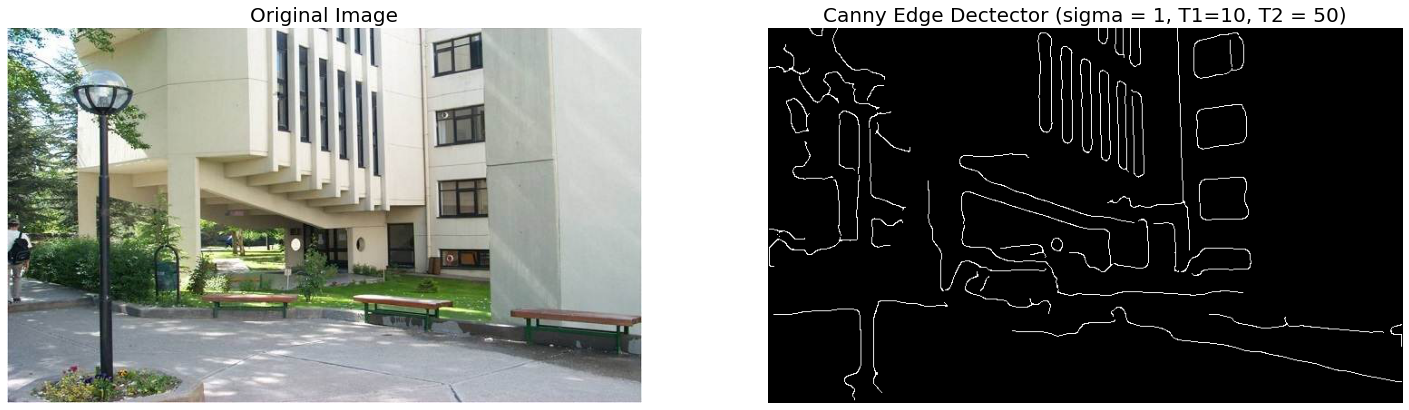

In [ ]:
# Canny Edge Detection
from skimage import io, feature, color
from skimage.util import img_as_ubyte
import matplotlib.pyplot as plt
import numpy as np
# Load image
!wget -cq https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/odtu_bm.jpeg
im_color = io.imread('odtu_bm.jpeg')
im = img_as_ubyte(color.rgb2gray(im_color))

edge_canny = feature.canny(im, sigma=1,low_threshold=10, high_threshold=50)
plt.figure(figsize=(25,15))
plt.subplot(1,2,1)
plt.imshow(im_color)
plt.axis('off')
plt.title('Original Image', fontsize=20 )
plt.subplot(1,2,2)
plt.imshow(edge_canny, cmap='gray')
plt.axis('off')
plt.title('Canny Edge Dectector (sigma = 1, T1=10, T2 = 50)', fontsize=20)  

## Edge Linking and Boundary Extraction

Although Canny or Marr Hildreth detectors are very successful to extract the object boundaries on simple images, they fall short to yield a closed boundary for relatively complex images. A further post processing step may be required for a complete  segmentation, which extracts the boundaries of objects.

For example, consider the output of a Canny edge detector of the skull x-ray, shown in Figure 24. One may need to measure the size of the skull. The edge map is too crowded to extract the boundary of the skull. One pragmatic way of extracting the boundary is to find  a circle which fits the edge map best.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/houghBrainex.png"  height=400px><figcaption>Figure 24: Fitting a circle to the output of Canny edge detector. (Original image courtesy of Dr. David R. Pickens, Vanderbilt University) </figcaption></p></figure>

**Q:** How can we fit an analytic function to a set of edge points?

There are a wide range of methods to extract object boundaries from an edge map. Among them, we shall provide only three methods:
1. Hough transform
2. Polygon approximation
3. Super slice method

Let us briefly discuss the above mentioned method.


## Hough Transform

Hough transform can be considered as a curve fitting method. Given a set of points, the goal is to find the parameters of an analytic function, which fits to a given set of points. 

Mathematically speaking, Hough transform fits the samples of a dataset, $D=\{x_i, y_i\}_{i=1}^n$ to a  function,  $y = f(x).$

In particular, the function can be an  $n^{th}$ order polynomial,
$$y=a_nx^n+a_{n-1}x^{n-1}+ \ldots a_0.$$

There are a wide range of methods to estimate the  parameter set $\{a_i\}_{i=1}^n$  of the polynomial. In this section we focus on the Hough transform method.

**Definition: Hough Transform  and Hough Space:** Given a function $y=f(x)$, with a parameter set, $\{a_i\}_{i=1}^n$, **Hough transform** is defined as a   mapping of all the points, $(x_i, y_i)$, which satisfy the function,  $y_i = f(x_i)$, in variable space, spanned by $(x,y)$  to the parameter space, spanned by $\{a_n\}$,

$$H: (x_i,y_i) \rightarrow\{a_n\}.$$


Note that, the domain of the Hough transform is spanned by the two dimensional variables, $(x,y)$ and the range is  spanned by the $n$-dimensional parameters, $\{a_n\}$.  


The range of the **Hough transform**, which is spanned by the parameter set , $\{a_n\}$ is called the Hough space.

*<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/houghxytoline.jpg"  height=300px><figcaption>Figure 25: Image space, spanned by the pixel coordinates $(x,y)$ is mapped to parameter space spanned by the parameters $\{a_n\}$. Dimension of the parameter space (right) depends on the order of the polynomial. For a line equation, $y=a_1x+a_0$,  the parameter space is two dimensional Cartesian space spanned by $a_0, a_1$. For a second order equation, $y= a_2 x^2 +a_1 x +a_0$,  it is a three dimensional Cartesian space, spanned by $a_0, a_1, a_2$. However, for higher dimensions, it is not possible to make a visually meaningful plot. This is the reason why we plot the Hough space with an amorphous shape. </figcaption></p></figure>

In image processing, Hough transform maps all the edge pixels from the two dimensional  image space, spanned by $(x,y)$ to the parameter space, spanned by the parameters of a function, $\{a_n\}$, as shown in Figure 25. 


**Q:** Given an edge map, how can we find the best parameter set, $\{a_i\}$ to fit a curve to a set of  edge pixels, in the Hough space?

Let's consider the simplest case, where we wish to fit a line to a set of edge pixels, in the following subsection.

### Hough Transform for Detection of Line Segments in Cartesian Coordinate system

Consider an edge map of Figure 26, which resembles a straight line. Our goal is to find the best parameters, $a$ and $b$ of the line equation,

$$y=ax+b$$

which fits a set of edge pixels.


*<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/houghlineex.jpg"  height=300px><figcaption>Figure 26:  How can we find the best parameters, $a$ and $b$  to fit a line,  $y=ax+b$ to a set of edge pixels. </figcaption></p></figure>

In this simple case, we define the Hough transform as a  mapping from the image space, spanned by  $(x,y)$ to Hough space, spanned by  $(a,b).$
$$H: \color{red}{y} = \color{black}{a} \color{red}{x}+\color{black}{b} \rightarrow \color{red}{b} = - \color{red}{a}\color{black}{x} + \color{black}{y}.$$

The basis vectors in image space are the variables, $(x,y)$,  and that of the Hough space are the parameters $(a,b)$,  of the line. Considering the fact that there is a unique parameter set $(a,b)$, which represents a straight line, the above Hough transform maps all the points on a straight line in the image space to a single point, with coordinates, $(a,b)$ in the Hough space, as shown in Figure 27. In other words, Hough transform maps a line in the image space to a single point in the Hough space,

$$H: line \rightarrow point.$$


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W12/hough1.png"  height=300px><figcaption>Figure 27:  All the points on a line in the image space is mapped to a single  point in the Hough space (right).</figcaption></p></figure>

  Similarly, consider infinitely many lines, each of which is represented by a unique parameter set, $a,b$,  passing from the same point, $(x,y)$. This point is represented by a straight line in the Hough space, as shown in Figure 28. In other words, Hough transform maps a  point in the image space to  infinitely many points on a straight line in the parameter space,

$$H: point \rightarrow line.$$

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/hough2.png"  height=300px><figcaption>Figure 28: A Point in the image space corresponds to line in the parameter space.</figcaption></p></figure>

The above analysis reveals that if we have a set of edge pixels on a straight line in the image space, these edge pixels will accumulate in a single point in the parameter space. This point is the coordinates of the parameter set of a line equation, which  fits the edge pixels best. Thus, we can partition the Hough space into a discrete grid and check for the most crowded cell in this grid to find the best parameters of the straight line to fit the edge pixels.


  **Definition:  Accumulator Cells, Accumulator Points**: Consider a partition in the Hough space into a discrete grid. Each cell in this space is called an accumulator cell, $A(p,q)$, where $(p,q)$ indicates the coordinate of the center of an accumulator cell. 

For each point $(x_i,y_i)$ in the image space, we can compute the corresponding parameter pair,

$$b_p = -a_qx_i+y_i, \quad \text{ for all } \quad a_{min} \leq a_q \leq a_{max} .$$

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/acccells.jpg"  height=300px><figcaption>

Figure 29: For each pixel coordinate $(x_i,y_i)$, in the image space, there are a set of points $(a_q, b_q)$, in the discrete grid of the parameter space (left).  </figcaption></p></figure>

For each point, $(x_i,y_i)$ in the image space, we compute $K$ accumulator points in parameter space for $$a_{min} \leq a_q \leq a_{max}, q=1,\ldots. K$$ The parameter set, which corresponds to the most crowded accumulator cell, gives the best line fit to the edge pixels.


**Algorithm: Hough Transform**

**Input**: Edge Map $\{x_k,y_k\}$ with  coordinates of edge pixels. Initialize, accumulator cells, $A(p,q) = 0$.
**Output**: Parameters, $(a,b)$ of the best line which fits the edge map.

Step 1: For every $(x_k, y_k)$ compute, 
$$b_q = -a_px_k+y_k, \  \text{for} \ a_{min}\leq a_p \leq a_{max}.$$
Step 2: Round $b_q$ to the nearest value of the coordinates of the accumulator cell.
Step 3: If a choice in $a_p$ is given to $b_q$, then, $$A(p,q) = A(p,q)+1$$
Step 4: Select the line with $M(a,b)=\max(A(p,q))$
Step 5: Form a line for $y=ax+b$



> Q: What happens when the line which fits the edge map is vertical or horizontal?

Considering the line equation, in the Cartesian coordinate system,
$$y =ax+b,$$

for the vertical lines,  the slope is $a \rightarrow \infty$. Similarly, for the horizontal lines, the intercept is,   $b\rightarrow \infty.$

In these cases, the limits of  accumulator cells, $(a_{min}, a_{max})$ or $(b_{min}, b_{max})$ are not bounded. Thus, the above Hough transform algorithm is not applicable to detect vertical and horizontal lines in the image.

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/houghSlope.jpg"  height=300px><figcaption>Figure 30: When the line in the image plane is vertical or horizontal, then the number of accumulator cells approach to infinity, in the Hough space. </figcaption></p></figure>

Therefore, the Cartesian coordinate system is not suitable for line detection using Hough transform. As an alternative, we can represent the line equation in the polar form, as explained below.

### Hough Transform for Detection of Line Segments in Polar form

It is possible to represent a line equation in polar form by setting,
$$x = \rho\cos\theta\ \ \text{ and}\ \ y=\rho\sin\theta,$$ 
where the magnitude square is,
$$\rho^2 = x^2+y^2$$
and the phase is,
$$ \theta = \tan^{-1}\frac{y}{x}.$$

The slope and intercept parameters, $(a,b)$, in the Cartesian system can be replaced by the magnitude and phase parameter set, $(\rho,\theta)$ of a line equation, in the polar system. Thus, we have equivalent representation of a line equation, with different parameter sets, in Cartesian and polar system,  as follows ;

$$y = ax+b \longleftrightarrow \rho  = x \cos\theta+y \sin\theta,$$
where the magnitude parameter, $\rho$ is the distance from the line to origin and the phase parameter,  $\theta$ is the angle between the $x$ axis and the direction of the magnitude. 

<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/houghPolar.jpg"  height=300px><figcaption>

Figure 31: A line segment in the image can be represented by Cartesian and polar form equivalently (left). The Hough space is spanned by the parameters $(\rho, \theta)$, of the polar representation (right).</figcaption></p></figure>


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W12/polar2.png"  height=300px><figcaption>

Figure 32: A vertical line in the image space is represented by a bounded parameter set, $(\rho,\theta)$, of polar form (left). A point on a line in the image space is represented by the linear combination of cosine and sine functions (right). </figcaption></p></figure>



Notice that, the parameters of a line equation in polar form are bounded in the Hough space: $$-90<\theta<90,$$
$$-D<\rho<D,$$

where D is the upper bound of $\rho$, determined by the size of the image.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image65_new.png" height=300px><figcaption>Figure 33: Each point of 1, 2, 3, 4 and 5 of the image space is represented by a different function in the Hough space. The intersections of these functions in the Hough space show the potential parameters of the line segments. We select the maximum intersection, which is either  the intersection of plots for 1, 3, 5 or  the intersection of the plots 2, 3, 4 . The other functions for point 1, 2 or 1, 4 or 4, 5  or 2, 5 have two intersections only. Thus, we eliminate the lines which pass from two points, in the image space. </figcaption></p></figure>

In most practical problems, the edge pixels do not precisely lie on a straight line, as shown in Figure 34. However, the edge pixels resemble a line. In these cases, the functions, corresponding to each edge pixel,  do not intersect at the same point , but they get very close in some regions of the Hough space, as shown in Figure 34 (left). Therefore selecting the size of the accumulator cell becomes a crucial design issue. The larger the accumulator cell, the looser fit to a line equation.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image73.png" height=300px><figcaption>

Figure 34: Each edge pixel in the image space in the left is represented by a function in the Hough space (right). Although the functions do not intersect at a single point, they get very close to each other. When we partition the Hough space into a grid of accumulator cells, the size of the cells defines the degree of approximation to fit a set of points to a line. Recall that the accumulator cell, which provides the maximum number of points shows the best parameter values for $(\rho, \theta).$ </figcaption></p></figure>

If we need to detect more than one line in the same image, then we sort the accumulator cells from the most crowded cell to the least crowded cell. Then, we select the most crowded K accumulator cells to fit K-lines to a given edge map. Obviously, this method does not provide a closed boundary for the objects, as shown in Figure 34. A post processing algorithm is required to prune the line segments which do not belong to the object boundary. There are a wide range of methods for pruning, depending on the application domain. In order to find a closed boundary of circular objects, we can use Hough transform for circle detection. 

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image75.png" height=300px><figcaption>

Figure 35: The boundaries of the image in the upper left image cannot be extracted by Hough transform, when we select $K$ of the most voted accumulator cells in the Hough space (upper right). The lines obtained at the output of the Hough transform meet most of the linelike boundary pixels (low). However, there are many spurious lines to be pruned. </figcaption></p></figure>


Detecting the lines by Hough transform does not yield closed boundaries for objects, as shown in Figure 35. When we select $K$ of the  most voted accumulator cells, we obtain $K$ lines.  Although these lines pass from the boundary pixels , there are many extensions to be pruned. A post processing algorithm is needed to prune the line segments obtained at the output of the Hough transform method.


**Programming exercises:**

1.   Run the following code to see how accumulator array changes when new points are added to the image.

Text(0, 0.5, 'nrho')

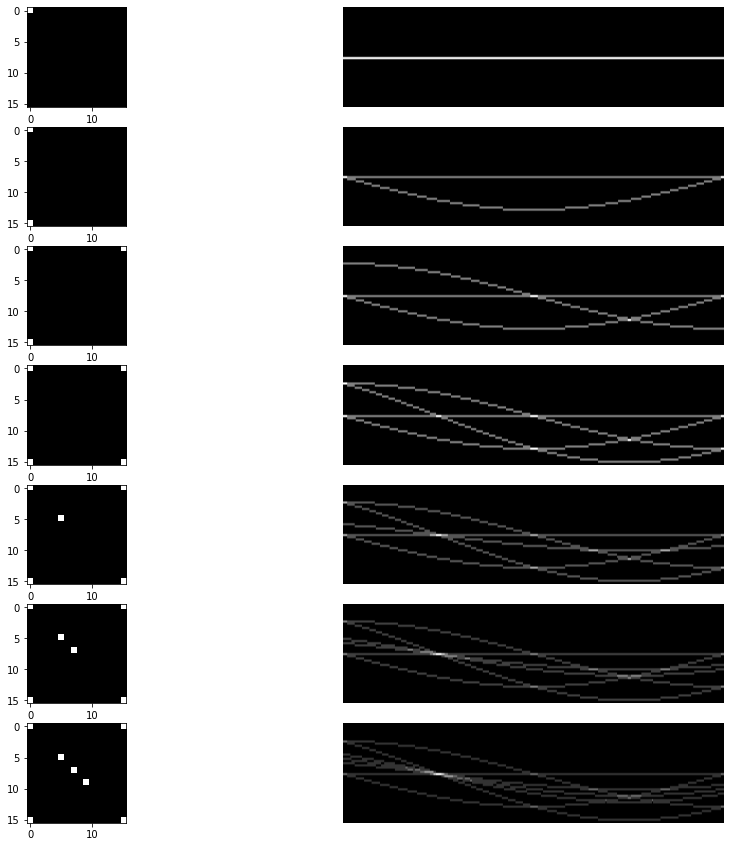

In [ ]:
# Hough transform
import numpy as np
from skimage.transform import hough_line

tested_angles = np.linspace(-np.pi / 2, np.pi / 2, 360, endpoint=False)
im =  np.zeros((16,16))
# Put the first white point
im[0,0]=1
#Transpose image to swap x and y axes before inputting it to hough_line function since this function accepts x and y as horizontal and vertical edges respectively.
#However, in xy-plane, x is the vertical edge and y is the horizontal edge.
H, theta, d=hough_line(im.T, theta =tested_angles)
# H is the accumulator array
angle_step = 0.5 * np.diff(theta).mean()
d_step = 0.5 * np.diff(d).mean()
bounds = [np.rad2deg(theta[0] - angle_step),
          np.rad2deg(theta[-1] + angle_step),
          d[-1] + d_step, d[0] - d_step]
# Plot accumulator array with the given bounds
plt.figure(figsize=(15,15))
plt.subplot(721), plt.imshow(im, cmap='gray') 
plt.subplot(722), 
plt.imshow(H, extent=bounds, cmap='gray')
plt.axis('off')
########################
# Put the second white point
im[15,0]=1
H, theta, d=hough_line(im.T, theta =tested_angles)
plt.subplot(723), plt.imshow(im, cmap='gray') 


angle_step = 0.5 * np.diff(theta).mean()
d_step = 0.5 * np.diff(d).mean()
bounds = [np.rad2deg(theta[0] - angle_step),
          np.rad2deg(theta[-1] + angle_step),
          d[-1] + d_step, d[0] - d_step]

plt.subplot(724), 
plt.imshow(H, extent = bounds, cmap='gray')
plt.axis('off')

########################
# Put the third white point
im[0,15]=1
H, theta, d=hough_line(im.T, theta =tested_angles)
plt.subplot(725), plt.imshow(im, cmap='gray') 


angle_step = 0.5 * np.diff(theta).mean()
d_step = 0.5 * np.diff(d).mean()
bounds = [np.rad2deg(theta[0] - angle_step),
          np.rad2deg(theta[-1] + angle_step),
          d[-1] + d_step, d[0] - d_step]

plt.subplot(726), 
plt.imshow(H, extent = bounds, cmap='gray')
plt.axis('off')

########################
# Put the fourth white point
im[15,15]=1
H, theta, d=hough_line(im.T, theta =tested_angles)
plt.subplot(727), plt.imshow(im, cmap='gray') 


angle_step = 0.5 * np.diff(theta).mean()
d_step = 0.5 * np.diff(d).mean()
bounds = [np.rad2deg(theta[0] - angle_step),
          np.rad2deg(theta[-1] + angle_step),
          d[-1] + d_step, d[0] - d_step]

plt.subplot(728), 
plt.imshow(H, extent = bounds, cmap='gray')
plt.axis('off')

##################
# Put the fifth white point
im[5,5]=1
H, theta, d=hough_line(im.T, theta =tested_angles)
plt.subplot(729), plt.imshow(im, cmap='gray') 


angle_step = 0.5 * np.diff(theta).mean()
d_step = 0.5 * np.diff(d).mean()
bounds = [np.rad2deg(theta[0] - angle_step),
          np.rad2deg(theta[-1] + angle_step),
          d[-1] + d_step, d[0] - d_step]

plt.subplot(7,2,10), 
plt.imshow(H, extent = bounds, cmap='gray')
plt.axis('off')

##################
# Put the sixth white point
im[7,7]=1
H, theta, d=hough_line(im.T, theta =tested_angles)
plt.subplot(7,2,11), plt.imshow(im, cmap='gray') 


angle_step = 0.5 * np.diff(theta).mean()
d_step = 0.5 * np.diff(d).mean()
bounds = [np.rad2deg(theta[0] - angle_step),
          np.rad2deg(theta[-1] + angle_step),
          d[-1] + d_step, d[0] - d_step]

plt.subplot(7,2,12), 
plt.imshow(H, extent = bounds, cmap='gray')
plt.axis('off')
plt.xlabel('ntheta')
plt.ylabel('nrho')

####################
# Put the seventh white point
im[9,9]=1
H, theta, d=hough_line(im.T, theta =tested_angles)
plt.subplot(7,2,13), plt.imshow(im, cmap='gray') 


angle_step = 0.5 * np.diff(theta).mean()
d_step = 0.5 * np.diff(d).mean()
bounds = [np.rad2deg(theta[0] - angle_step),
          np.rad2deg(theta[-1] + angle_step),
          d[-1] + d_step, d[0] - d_step]

plt.subplot(7,2,14), 
plt.imshow(H, extent = bounds, cmap='gray')
plt.axis('off')
plt.xlabel('ntheta')
plt.ylabel('nrho')

### Hough Transform for Detecting Circles

This time, our goal is to fit a circle to a given set of edge pixels. Recall that a circle equation in Cartesian form is defined by three parameters, $(x_0, y_0, d),$ as follows;

 $$(x-x_0)^2+(x-x_0)^2 = \rho^2,$$ 

where $(x_0,y_0)$ is  the coordinate of the center  and $\rho$ is the radius of the circle. Since there are three parameters of the circle equation, the Hough space is a three dimensional parameter space. 

Suppose  that the diameter $\rho$ is given. Then, the Hough space is spanned by the  coordinates of the center of the circle , $(x_0,y_0)$. Each point of a circle in the image space is mapped to a circle in the Hough space (See; Figure 36). Then, the Hough transform for line detection algorithm can be easily adapted to the circle detection algorithm to find the best set of parameters, $(x_0,y_0)$,  in the   two-dimensional Hough space.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image82.png" height=300px><figcaption>
Figure 36: Each point, $(x_i, y_i)$,  on a circle of a  known radius in the image space is represented by a circle in the Hough space.  Then, the  center coordinates, $(x_0, y_0)$, of a circle, which fits the edge points  best, is obtained  at which the accumulator cell $A(x_0,y_0)$ gets the most votes.</figcaption></p></figure>

In practical problems, the radius of the circle is not known. Thus,  the three dimensional Hough space is spanned by the  parameters, $(x_0, y_0, \rho)$  of a circle. As a result, a point $(x_i, y_i)$ in image space is mapped to a cone in the Hough space, as shown in Figure 36.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image83.png" height=300px><figcaption>
Figure 37: A point on a circle is mapped into a cone in the Hough space. 
</figcaption></p></figure>

This approach is quite expensive to find the best parameter set of a circle.  Computational complexity can be reduced by using the direction of the gradient at each edge pixel, as shown in Figure: 37. 

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image84.png" height=300px><figcaption>
Figure 38: The direction of an edge pixel heads to the center of a circle. 
</figcaption></p></figure>

It is very likely that the center of a circle lies on a line in the direction, $\theta$  of an edge pixel. Therefore, we represent each edge pixel of the image plane by a line of slope $\theta$, in the Hough space, In summary, an edge point $(x_i,y_i)$ of an image space  is mapped to a line, in the three dimensional Hough space,  as shown in Figure 37. Then, the intersection of all the lines in the gradient direction of all the edge pixels,  in the Hough space gives us the best parameter set.

**Programming exercises:**

1.   Run the following code to detect the coins (circles) in the image.

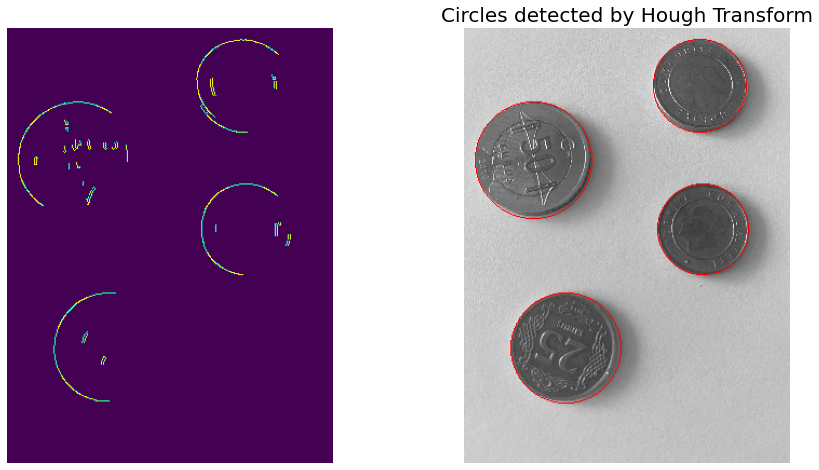

In [ ]:
# Hough transform for detecting circles
from skimage import feature, io, color
from skimage.util import img_as_ubyte
import matplotlib.pyplot as plt
import numpy as np
from skimage.transform import hough_circle, hough_circle_peaks
from skimage.draw import circle_perimeter
from skimage.transform import rescale

# Load image and rescale it
!wget -cq https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/paralar.jpeg
image = img_as_ubyte(color.rgb2gray(io.imread('paralar.jpeg')))
image = rescale(image, 0.1, anti_aliasing=False)

# Detect edges using Canny edge detector
edges = feature.canny(image, sigma=0.3, low_threshold=1, high_threshold=2)

# Define a set of radii and run hough circle detector 
hough_radii = np.arange(20, 60, 1)
hough_res = hough_circle(edges, hough_radii)

# Select 4 circles (there are 4 coins in the image)
accums, cx, cy, radii = hough_circle_peaks(hough_res, hough_radii,total_num_peaks=4)

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(15, 8))
image = color.gray2rgb(image)
for center_y, center_x, radius in zip(cy, cx, radii):
    circy, circx = circle_perimeter(center_y, center_x, radius,
                                    shape=image.shape)
    image[circy, circx] = (1, 0, 0)

plt.title('Circles detected by Hough Transform', fontsize=20 )
ax[0].imshow(edges)
ax[0].axis('off')
ax[1].imshow(image, cmap=plt.cm.gray)
plt.axis('off')
plt.show()



### Application of Hough Transform

The success of the Hough transform method for detecting the lines, circles or higher order polynomials depend on the image content.  It gives very satisfactory results in applications, where there are line-like structures, such as highways or airports, as shown in Figure 39. 

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image72.png" height=300px><figcaption>Figure 39: (a) A 502x564 aerial image of an airport. (b) Edge image obtained using Canny;s algorithm. (c) Hough parameter space (The boxes highlight the points associated with long vertical lines). (d) Lines in the image plane corresponding to the points highlighted by the boxes.) (e) Lines superimposed on the original image. (From Gonzales and Woods)</figcaption></p></figure>

In some cases we are just interested in detecting the line-like structure. Hough transform successfully extracts the lines in a given image as shown in Figure 40.

Note that as the degree of polynomial gets higher, the computational complexity of the algorithms increases. 

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/image71.png" height=300px><figcaption>Figure 40: (a) Infrared image. (b) Thresholded gradient image. (c) Hough transform (d) Linked pixels.  (From Gonzales and Woods, Courtesy of Mr. D.R. Cate, Texas Instruments, Inc.)</figcaption></p></figure>


In summary,
- Hough transform approximates  a parametric function, which fits an edge map best.
- If the parameters are $p_1, p_2, \ldots p_n$, then the Hough transform uses an n-dimensional accumulator array in which it accumulates votes for the correct parameters of the lines or curves found on the image.

<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/houghf1.jpg" height=300px><figcaption>Figure 41:  (Adapted from Linda Shapiro, U of Washington)</figcaption></p></figure>





## Polygon Approximation to an Edge Map of a Single Object 

Suppose that we are given an   edge map of a low noise image and we are asked to fit a polygon to the edge map (see:  Figure. 46 (left)).  If there is only one object with a background in the image, we can fit a polygon to this set of edges by a simple algorithm. As an example, we can  find two farthest points in the edge map and label them as two vertices. As a second step, we  draw a line between the two vertices.  As a third step, we can find the farthest edge pixel to the line, and measure the distance, $d$. If this distance is larger than a predefined threshold value, $T$, then, we assign this pixel as a vertex of the  polygon and find the lines between this new vertex and the previously detected vertices. We repeat adding vertices to the list of vertices and measuring the distances $d$ until  we reach $d \lt T.$


<figure><p  align="center"><img  src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W13/borderwpolygons.png"  height=300px><figcaption>Figure  42: Edge map of a low noise image (left) and the first step of the polygon approximation (right).</figcaption></p></figure>

**Algorithm: Polygon Approximation to a Single Object **
**Input** Edge map, threshold $T$, List of vertices, $L$.
**Output** Object boundary with polygon

Step 1. Find two farthest edge pixels, $p_i$, and $p_j$ add these pixels to $L$.
Step 2. Connect  $p_i$, and $p_j$ by a straight line.
Step 3. Find the farthest edge pixel from the line(s) and measure the distance, $d$ between the line and the farthest pixel :  if the distance $d \ge T$, label this edge pixel as a vertex, $p_k$ ,  add it to the list of vertices and remove the line between  $p_i$, and $p_j$ , else go to step 5
Step 4. Connect  $p_i$, and $p_k$,  and $p_j$, and $p_k$ by two straight lines
Step 5. Repeat Step 3 and 4 until $d<T$ for all the lines between the edge pixels.

The above algorithm fits only a convex polygon to the edge map. If the polygon is concave, one needs to revise the above  algorithm by detecting the inside and outside of the object with a contour following method. 


## Superclice Method
 
In some applications the image may consist of objects with dominant colors and a smooth background. If we extract the edge map of these types of image, we obtain incomplete boundaries around the objects, as shown in Figure:23. The best set of the thresholds to partition the modes of the histogram can be obtained by maximizing the match between the boundaries of the segmentation map obtained by histogram thresholding and the output of the edge detection algorithm. Thus, we can iteratively adjust the threshold values so that the segmentation map obtained from the histogram thresholding method has maximum match to the edge map.
 
<figure><p align="center"><img src="https://raw.githubusercontent.com/hazalmogultay/466Images/master/W12/edge_map.png" height=600px><figcaption>Figure 23: Super Slice Segmentation Method: a) Original image, b) Edge map obtained by canny edge detection algorithm c) Segmentation map obtained by histogram thresholding. The histogram threshold value for segmenting the image in (a) is adjusted by finding the maximum overlaps of the boundaries of the segmentation map, given in (c) and that of the edge map, given in (b).</figcaption></p></figure>
 
**Algorithm: Super Slice Segmentation Methods**
 
**Input**: Image $c_i=f(x,y)$, number of clusters, $K$.
 
**Output**: A set of threshold values and a segmentation map
 
1. Find the edge map of an image using an edge detection algorithm.
 
2. Find color histogram of the image
3. Use different threshold sets to obtain the segmentation maps by histogram thresholding.
3.Select the threshold value set, which coincides with boundary segments of the edge map, best.
 
Super slice method fails, when the objects or the background of the image is textured, which results in many spurious edges other than the boundary pixels. In such a case, it is useful to use a smoothing filter for removing the texture of the objects and the background.
 


# Chapter Summary

In region based segmentation, we assumed that an object can be represented by a homogeneous region or collection of homogeneous regions, with respect to a similarity predicate. Is this  a valid assumption for all kinds of objects? How do we define an object, anyway? How can we extract objects, which consists of heterogeneous regions?

Unfortunately, objects may not always  consist of homogeneous regions. In fact, there is no generic definition of an object in terms of color, texture  or shape constituents. Although the concept of object is well-studied in many fields of science, there is no universal  definition, which covers all the objects. For example, a bicycle  consists of  a saddle, a handle bar, a pair of pedals, two circular shaped wheels connected by cylindrical frames. Therefore, it barely consists of homogeneous parts. In order to extract this types of objects, it is better to develop segmentation algorithms based on the shapes or dissimilarity metrics.

Gestalt theory provides a set of  rules for aggregating the heterogeneous object parts. Although they are helpful for developing the region-based segmentation algorithms, they fall short to develop complete segmentation of meaningful objects.   In this chapter, we studied edge based segmentation methods, where dissimilarities between  regions are more important then the similarities within the regions. 

There are two major steps of edge based segmentation: The first one is to extract an edge map using one of the gradient or Laplacian filters. The second one is to form a closed boundary from the edge map. When the objects are rather simple Marr-Hildreth or Canny edge detectors are sufficient to find the boundary of an object. Unfortunately, most of the objects  consist of multiple heterogeneous regions with cluttered background. If we have an idea about the analytic shapes of objects, we can apply curve fitting methods to estimate the parameters of the function, which represents the object boundary. A very popular curve fitting method is Hough transforms, where we estimate the parameters of an analytic function in Hough space. If the analytical form of an object boundary is now known, then we can approximate the edge map by a polygon. 

Finally, we can combine the region and edge based segmentation methods to boost the output of single algorithms. Super slice method is an example of combining multiple segmentation algorithms, where we improve the result of region based segmentation by finding the maximum boundary overlaps between the region and edge based segmentation methods.




